In [1]:
from scapy.all import rdpcap, IP, UDP, TCP, PcapReader
import matplotlib.pyplot as plt
import numpy as np
import subprocess

import os
os.chdir(f"{os.getenv("HOME")}/sidekick-downloads/")

In [2]:
pcap_server_fp = "/tmp/sidekick-logs/h2-eth0.pcap"
pcap_proxy_server_fp = "/tmp/sidekick-logs/p1-eth1.pcap"
pcap_client_fp = "/tmp/sidekick-logs/h1-eth0.pcap"
pcap_proxy_client_fp = "/tmp/sidekick-logs/p1-eth0.pcap"

In [15]:
labels = {
    "172.16.2.10" : "sender",
    "172.16.1.12" : "proxy_s",
    "172.16.1.11" : "proxy_r",
    "172.16.1.10" : "receiver",
    "172.16.1.21" : "tunnel (.21)",
    "172.16.1.22" : "tunnel (.22)"
}

# Data Transmitted

In [16]:
BIN_SIZE = 0.1 # 100ms

def bytes_ts(pcap, proto=UDP):
    first_ts = None
    # Flow -> { bin : nbytes }
    series = {}   # key = (src, dst), value = dict{bin_index -> bytes} 
    for pkt in pcap:
        if IP not in pkt or proto not in pkt:
            continue

        if first_ts is None:
            first_ts = pkt.time
        
        bin_idx = int((pkt.time - first_ts) // BIN_SIZE)
        size = len(bytes(pkt[proto].payload))
        src = pkt[IP].src if pkt[IP].src not in labels else labels[pkt[IP].src]
        dst = pkt[IP].dst if pkt[IP].dst not in labels else labels[pkt[IP].dst]
        key = f"{src}->{dst}"
        if key not in series:
            series[key] = {}
        series[key][bin_idx] = series[key].get(bin_idx, 0) + size

    # Duration of all flows (number of BIN_SIZE-second bins) 
    max_bin = 0
    for d in series.values():
        if d:
            max_bin = max(max_bin, max(d.keys()))
    # x-axis
    bins = np.arange(max_bin + 1) * BIN_SIZE

    # Fill out with zeroes if needed
    dense_series = {}
    for key, counts in series.items():
        dense_series[key] = np.zeros(max_bin + 1)
        for bin_idx, val in counts.items():
            dense_series[key][bin_idx] = val

    dense_series_mbps = {k: v * 8 / 1_000_000 / BIN_SIZE for k, v in dense_series.items()}
    return bins, dense_series_mbps

In [147]:
YMAX = 30.0

def plot_bytes_time_series(bins, dense_series, label, ax):
    
    for direction, arr in dense_series.items():
        ax.plot(bins, arr, label=str(direction))
    
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(f"Mbps")
    ax.set_ylim(0, YMAX)
    # ax.set_xlim(0, 5)
    ax.set_title(f"Mbps per {int(BIN_SIZE * 1000)}ms interval ({label})")
    ax.legend()

In [55]:
def plot_all(title="", with_proxy=True):
    server_pkts = rdpcap(pcap_server_fp)
    client_pkts = rdpcap(pcap_client_fp)
    if with_proxy:
        proxy_clientside_pkts = rdpcap(pcap_proxy_client_fp)
        proxy_serverside_pkts = rdpcap(pcap_proxy_server_fp)

    server_bins, server_ts = bytes_ts(server_pkts)
    if with_proxy:
        proxy_s_bins, proxy_s_ts = bytes_ts(proxy_serverside_pkts)
        proxy_c_bins, proxy_c_ts = bytes_ts(proxy_clientside_pkts)
    client_bins, client_ts = bytes_ts(client_pkts)

    # TODO save data

    nfig_x = 2 if with_proxy else 1
    fig_size = (12, 12) if with_proxy else (12, 6)
    fig, axes = plt.subplots(nfig_x, 2, figsize=fig_size)
    axes_flat = axes.flatten()
    
    plot_bytes_time_series(server_bins, server_ts, "sender", axes_flat[0])
    if with_proxy:
        plot_bytes_time_series(proxy_s_bins, proxy_s_ts, "proxy-s", axes_flat[1])
        plot_bytes_time_series(proxy_c_bins, proxy_c_ts, "proxy-r", axes_flat[2])
    plot_bytes_time_series(client_bins, client_ts, "receiver", axes_flat[3 if with_proxy else 1])

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Run

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 30 --ge 0.2,3,80,2 -t 1 --proxy picoquic picoquic --congestion-control bbr -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 bbr &
[SIDEKICK:DEBUG] p1 ./deps/picoquic/picoquic_sample proxy 10800 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key bbr 4433 172.16.2.10 &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.1.11 10800 /tmp bbr /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-11-28 19:16:59", "proxy_type": "picoquic", "data_size": 50000000, "cca": "bbr"}, "outputs": [{"success": true, "timeout": false, "time_s": 39.311529, "throughput_mbps": 10.17513208402553, "additional_data": {"num_spurious_receiver": 226, "num_spurious_sender": 0}}]}
sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 30 --ge 0.2,3,80,2 -t 1 --proxy picoquic picoquic --congestion-control bbr -n 50000000


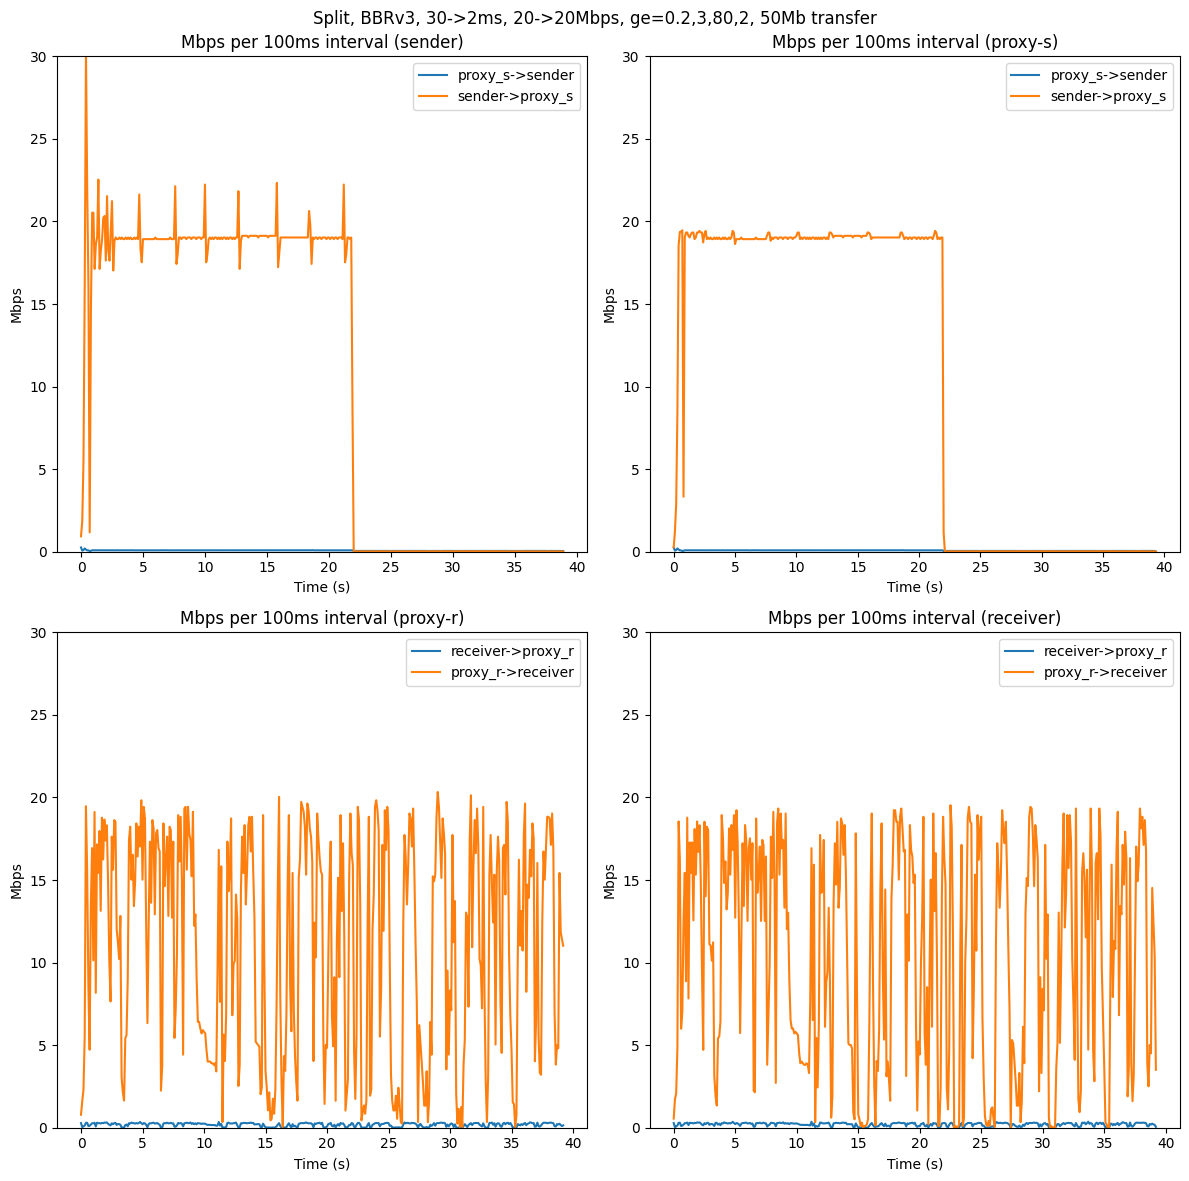

In [110]:
bw1 = 20
bw2 = 20
delay2 = 30
delay1 = 2
ge = "0.2,3,80,2"
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw1} --bw2 {bw2} --delay1 {delay1} --delay2 {delay2} "
          f"--ge {ge} -t 1 "
          f"--proxy picoquic "
          f"picoquic "
          f"--congestion-control bbr "
          f"-n {bytes_}")
print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(cmd)

plot_all(f"Split, BBRv3, {delay2}->{delay1}ms, {bw2}->{bw1}Mbps, ge={ge}, {mbyte}Mb transfer")

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 0 --delay2 2  --ge 0.2,3,80,2 -t 1 picoquic --congestion-control bbr -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 bbr &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp bbr /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-11-28 19:33:46", "proxy_type": "none", "data_size": 50000000, "cca": "bbr"}, "outputs": [{"success": true, "timeout": false, "time_s": 118.451712, "throughput_mbps": 3.376903492960912, "additional_data": {"num_spurious_receiver": 510, "num_spurious_sender": 0}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 0 --delay2 2  --ge 0.2,3,80,2 -t 1 picoquic --congestion-control bbr -n 50000000', returncode=0)


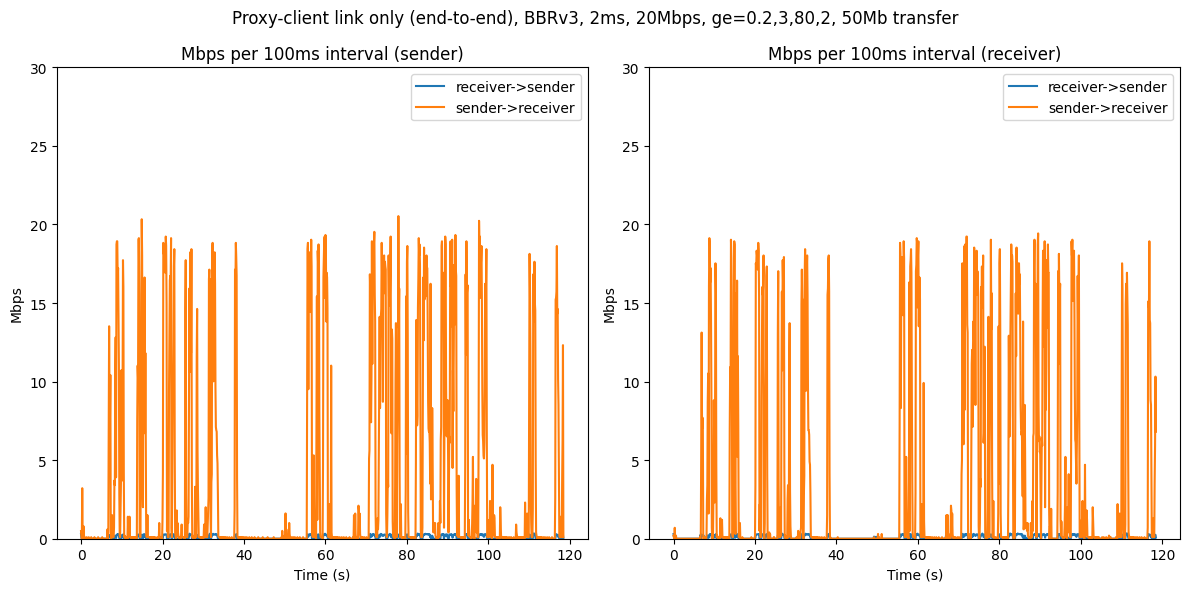

In [120]:
bw = 20
delay = 2
ge = "0.2,3,80,2"
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 0 --delay2 {delay}  "
          f"--ge {ge} -t 1 "
          f"picoquic "
          f"--congestion-control bbr "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)
plot_all(f"Proxy-client link only (end-to-end), BBRv3, {delay}ms, {bw}Mbps, ge={ge}, {mbyte}Mb transfer", with_proxy = False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 0 --delay2 30  --loss1 0 --loss2 0 -t 1 picoquic --congestion-control bbr -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 bbr &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp bbr /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-11-28 19:32:52", "proxy_type": "none", "data_size": 50000000, "cca": "bbr"}, "outputs": [{"success": true, "timeout": false, "time_s": 21.595436, "throughput_mbps": 18.5224322398492, "additional_data": {"num_spurious_receiver": 0, "num_spurious_sender": 0}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 0 --delay2 30  --loss1 0 --loss2 0 -t 1 picoquic --congestion-control bbr -n 50000000', returncode=0)


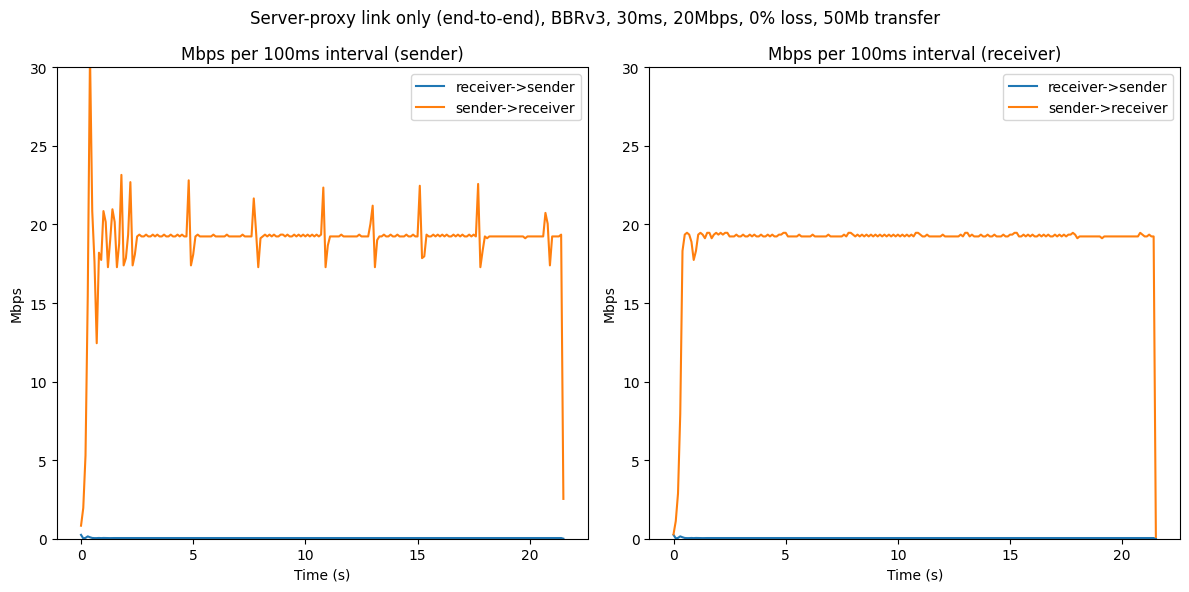

In [119]:
bw = 20
delay = 30
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 0 --delay2 {delay}  "
          f"--loss1 0 --loss2 0 -t 1 "
          f"picoquic "
          f"--congestion-control bbr "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)
plot_all(f"Server-proxy link only (end-to-end), BBRv3, {delay}ms, {bw}Mbps, 0% loss, {mbyte}Mb transfer", with_proxy = False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 10 --ge 0.2,3,80,2 -t 1 --proxy picoquic picoquic --congestion-control bbr -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 bbr &
[SIDEKICK:DEBUG] p1 ./deps/picoquic/picoquic_sample proxy 10800 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key bbr 4433 172.16.2.10 &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.1.11 10800 /tmp bbr /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-11-28 19:19:01", "proxy_type": "picoquic", "data_size": 50000000, "cca": "bbr"}, "outputs": [{"success": true, "timeout": false, "time_s": 39.875219, "throughput_mbps": 10.031292868886814, "additional_data": {"num_spurious_receiver": 381, "num_spurious_sender": 0}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 10 --ge 0.2,3,80,2 -t 1 --proxy picoquic picoquic --congestion-control bbr -n 50000000', returncode=0)


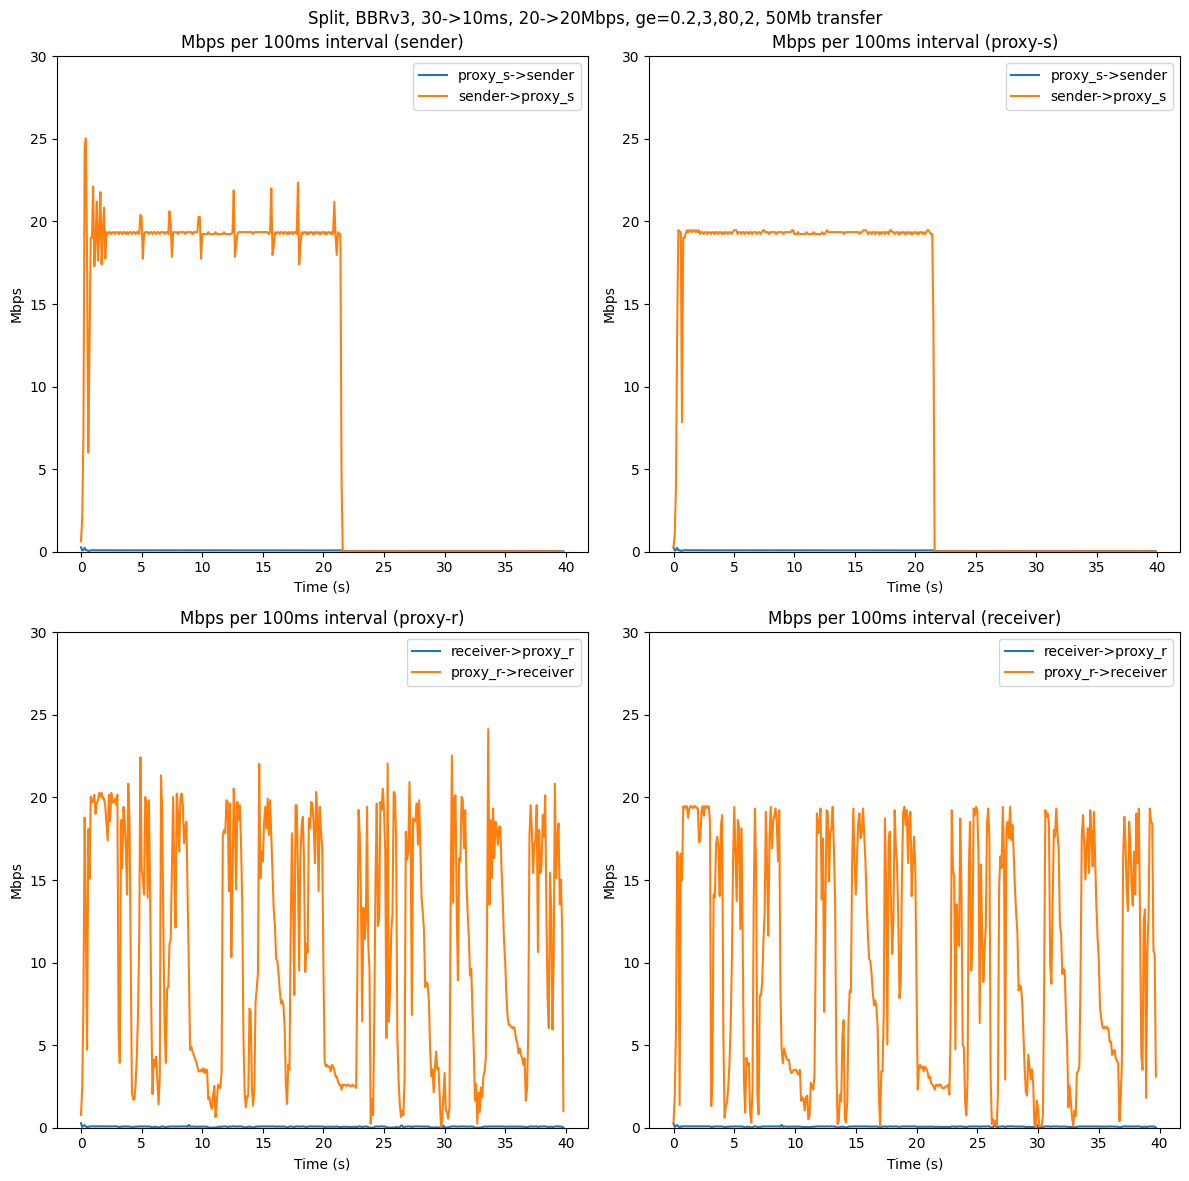

In [111]:
# Split - longer delay
bw1 = 20
bw2 = 20
delay2 = 30
delay1 = 10
ge = "0.2,3,80,2"
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw1} --bw2 {bw2} --delay1 {delay1} "
          f"--ge {ge} -t 1 "
          f"--proxy picoquic "
          f"picoquic "
          f"--congestion-control bbr "
          f"-n {bytes_}")
print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)
plot_all(f"Split, BBRv3, {delay2}->{delay1}ms, {bw2}->{bw1}Mbps, ge={ge}, {mbyte}Mb transfer")

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 0 --delay2 10  --ge 0.2,3,80,2 -t 1 picoquic --congestion-control bbr -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 bbr &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp bbr /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-11-28 19:42:11", "proxy_type": "none", "data_size": 50000000, "cca": "bbr"}, "outputs": [{"success": true, "timeout": false, "time_s": 63.78182, "throughput_mbps": 6.271379524761131, "additional_data": {"num_spurious_receiver": 163, "num_spurious_sender": 7}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 0 --delay2 10  --ge 0.2,3,80,2 -t 1 picoquic --congestion-control bbr -n 50000000', returncode=0)


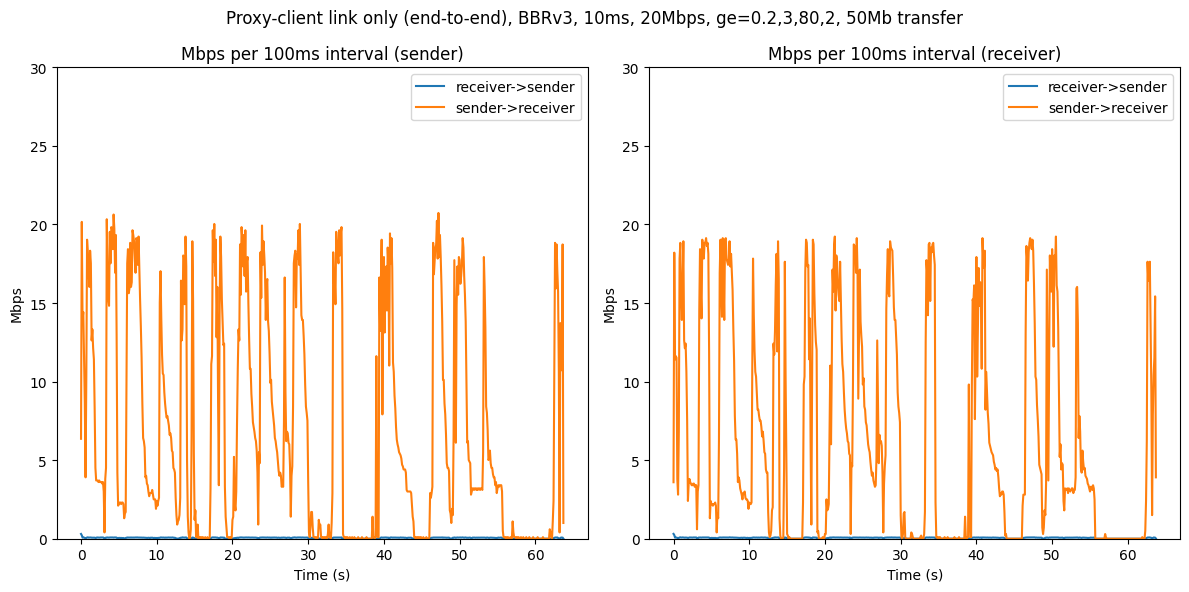

In [122]:
# Isolated 10ms link
bw = 20
delay = 10
ge = "0.2,3,80,2"
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 0 --delay2 {delay}  "
          f"--ge {ge} -t 1 "
          f"picoquic "
          f"--congestion-control bbr "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)
plot_all(f"Proxy-client link only (end-to-end), BBRv3, {delay}ms, {bw}Mbps, ge={ge}, {mbyte}Mb transfer", with_proxy = False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 30  --ge 0.2,3,80,2 -t 1 --proxy picoquic picoquic --congestion-control cubic -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 cubic &
[SIDEKICK:DEBUG] p1 ./deps/picoquic/picoquic_sample proxy 10800 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key cubic 4433 172.16.2.10 &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.1.11 10800 /tmp cubic /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-11-28 19:24:36", "proxy_type": "picoquic", "data_size": 50000000, "cca": "cubic"}, "outputs": [{"success": true, "timeout": false, "time_s": 24.197537, "throughput_mbps": 16.53060805320806, "additional_data": {"num_spurious_receiver": 420, "num_spurious_sender": 0}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 30  --ge 0.2,3,80,2 -t 1 --proxy picoquic picoquic --congestion-control cubic -n 50000000', returncode=0)


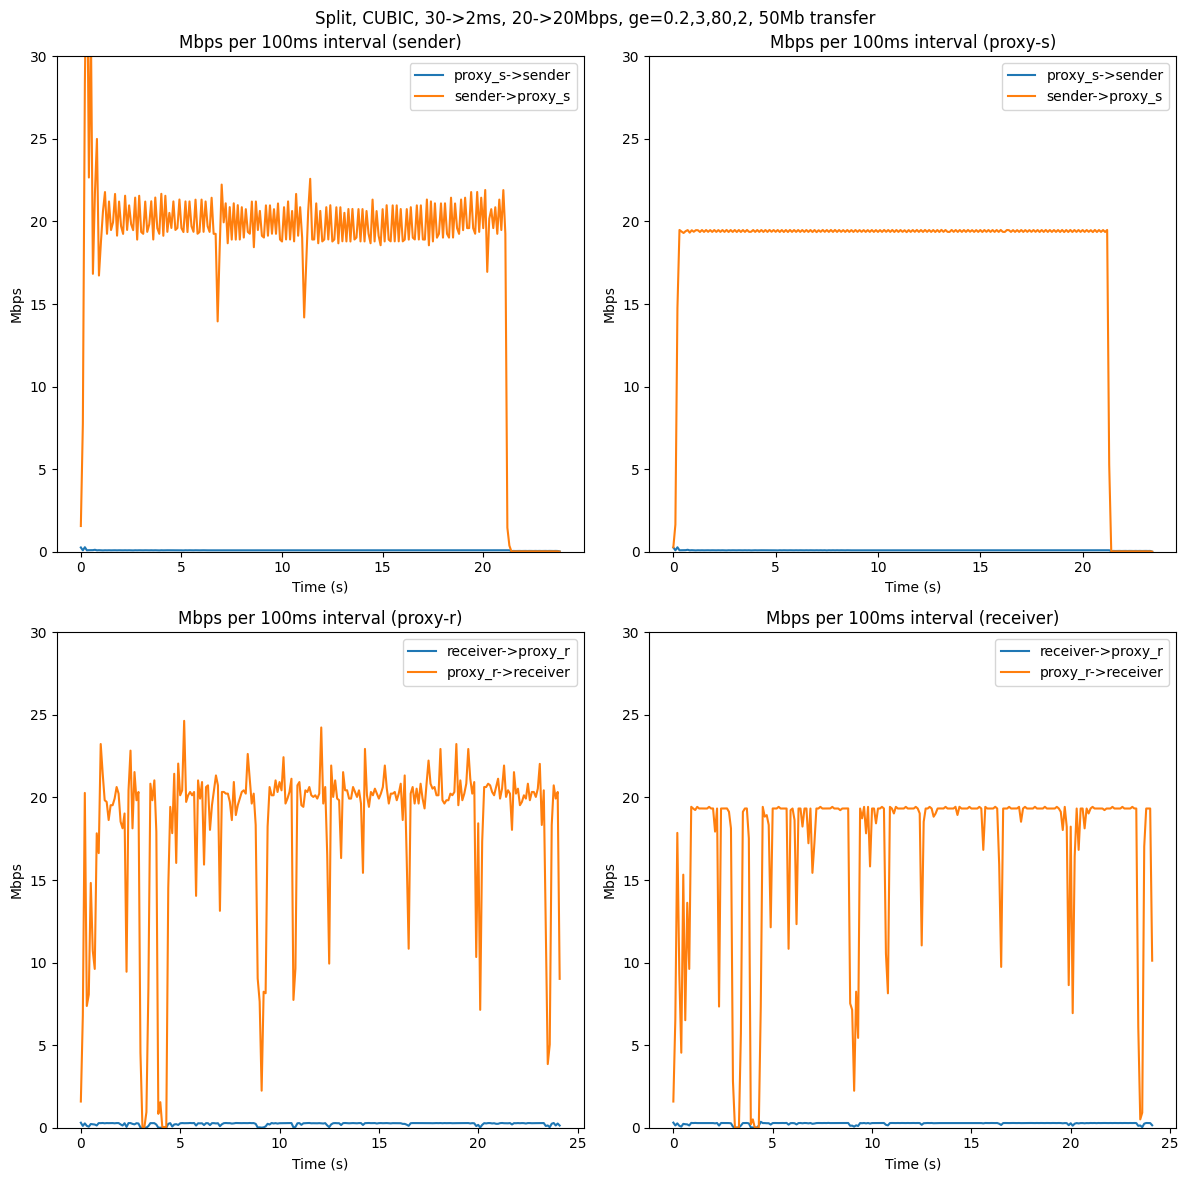

In [114]:
# Split - CUBIC - over 2ms
bw1 = 20
bw2 = 20
delay2 = 30
delay1 = 2
ge = "0.2,3,80,2"
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw1} --bw2 {bw2} --delay1 {delay1} --delay2 {delay2}  "
          f"--ge {ge} -t 1 "
          f"--proxy picoquic "
          f"picoquic "
          f"--congestion-control cubic "
          f"-n {bytes_}")
print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)

plot_all(f"Split, CUBIC, {delay2}->{delay1}ms, {bw2}->{bw1}Mbps, ge={ge}, {mbyte}Mb transfer")

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --ge 0.2,3,80,2 -t 1 picoquic --congestion-control bbr -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 bbr &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp bbr /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-12-01 12:58:20", "proxy_type": "none", "data_size": 50000000, "cca": "bbr"}, "outputs": [{"success": true, "timeout": false, "time_s": 120.152651, "throughput_mbps": 3.3290984149821212, "additional_data": {"num_spurious_receiver": 362, "num_spurious_sender": 2}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --ge 0.2,3,80,2 -t 1 picoquic --congestion-control bbr -n 50000000', returncode=0)


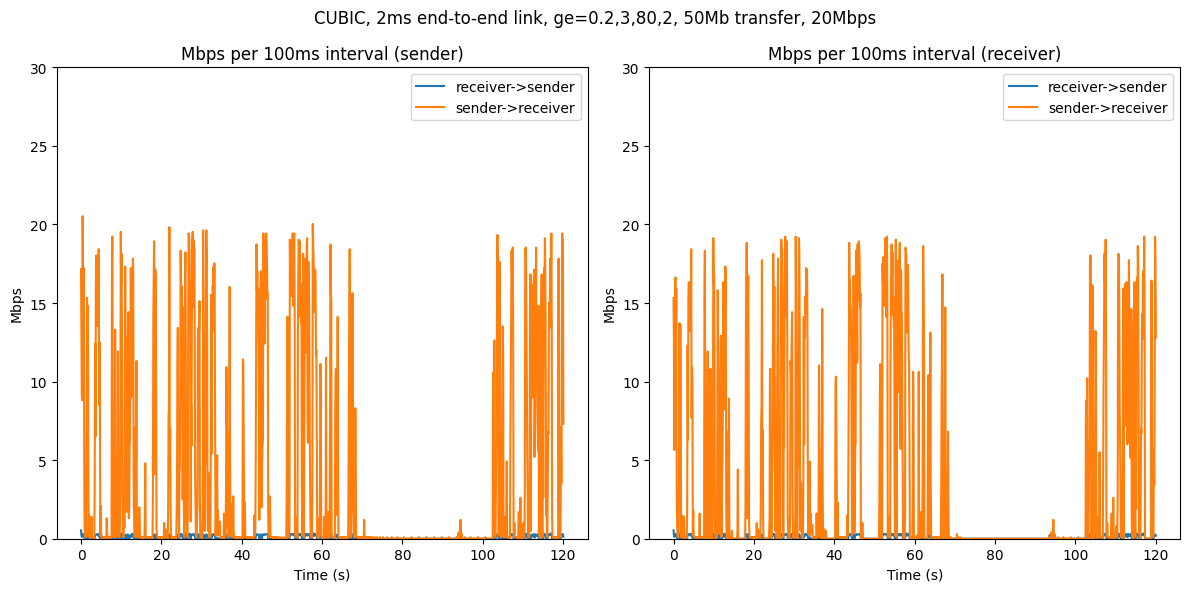

In [139]:
# 2ms delay - CUBIC
bw = 20
delay = 2
ge = "0.2,3,80,2"
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 {delay} --delay2 0  "
          f"--ge {ge} -t 1 "
          f"picoquic "
          f"--congestion-control bbr "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)

plot_all(f"CUBIC, {delay}ms end-to-end link, ge={ge}, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --loss1 0 -t 1 picoquic -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 cubic &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp cubic /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-12-01 12:47:13", "proxy_type": "none", "data_size": 50000000, "cca": "cubic"}, "outputs": [{"success": true, "timeout": false, "time_s": 21.104444, "throughput_mbps": 18.953354089783176, "additional_data": {"num_spurious_receiver": 0, "num_spurious_sender": 0}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --loss1 0 -t 1 picoquic -n 50000000', returncode=0)


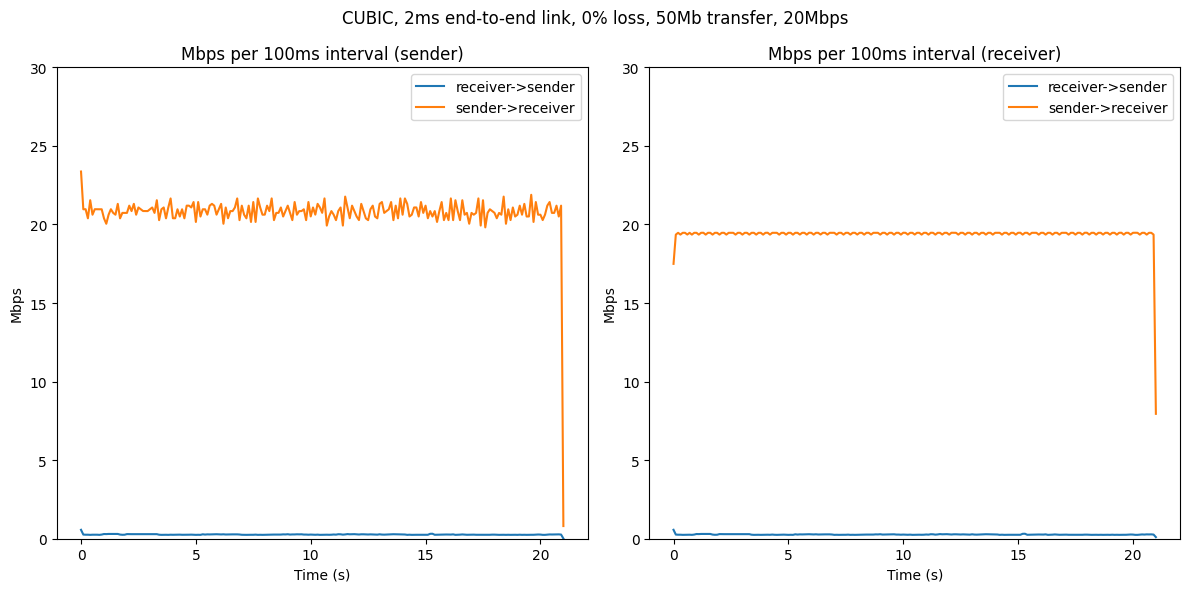

In [132]:
# 2ms delay - CUBIC
bw = 20
delay = 2
loss = 0
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 {delay} --delay2 0  "
          f"--loss1 {loss} -t 1 "
          f"picoquic "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)

plot_all(f"CUBIC, {delay}ms end-to-end link, {loss}% loss, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --loss1 0.1 -t 1 picoquic -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 cubic &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp cubic /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-12-01 12:48:14", "proxy_type": "none", "data_size": 50000000, "cca": "cubic"}, "outputs": [{"success": true, "timeout": false, "time_s": 21.121048, "throughput_mbps": 18.938454190341314, "additional_data": {"num_spurious_receiver": 0, "num_spurious_sender": 0}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --loss1 0.1 -t 1 picoquic -n 50000000', returncode=0)


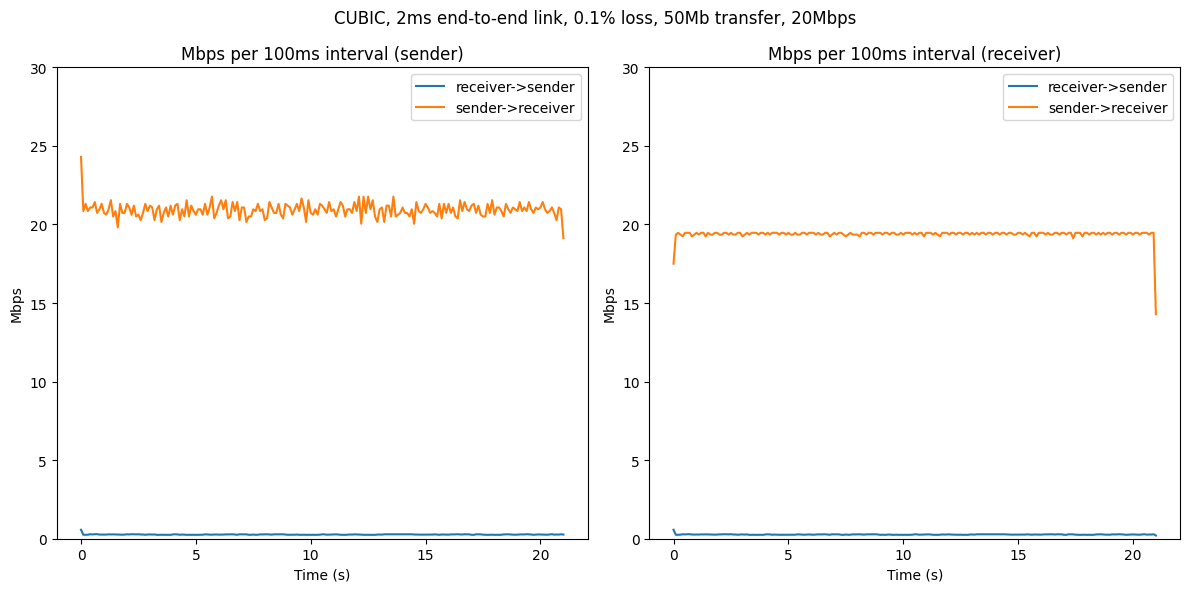

In [133]:
# 2ms delay - CUBIC
bw = 20
delay = 2
loss = 0.1
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 {delay} --delay2 0  "
          f"--loss1 {loss} -t 1 "
          f"picoquic "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)

plot_all(f"CUBIC, {delay}ms end-to-end link, {loss}% loss, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --loss1 1 -t 1 picoquic -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 cubic &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp cubic /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-12-01 12:49:15", "proxy_type": "none", "data_size": 50000000, "cca": "cubic"}, "outputs": [{"success": true, "timeout": false, "time_s": 21.32203, "throughput_mbps": 18.75993983687294, "additional_data": {"num_spurious_receiver": 0, "num_spurious_sender": 0}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --loss1 1 -t 1 picoquic -n 50000000', returncode=0)


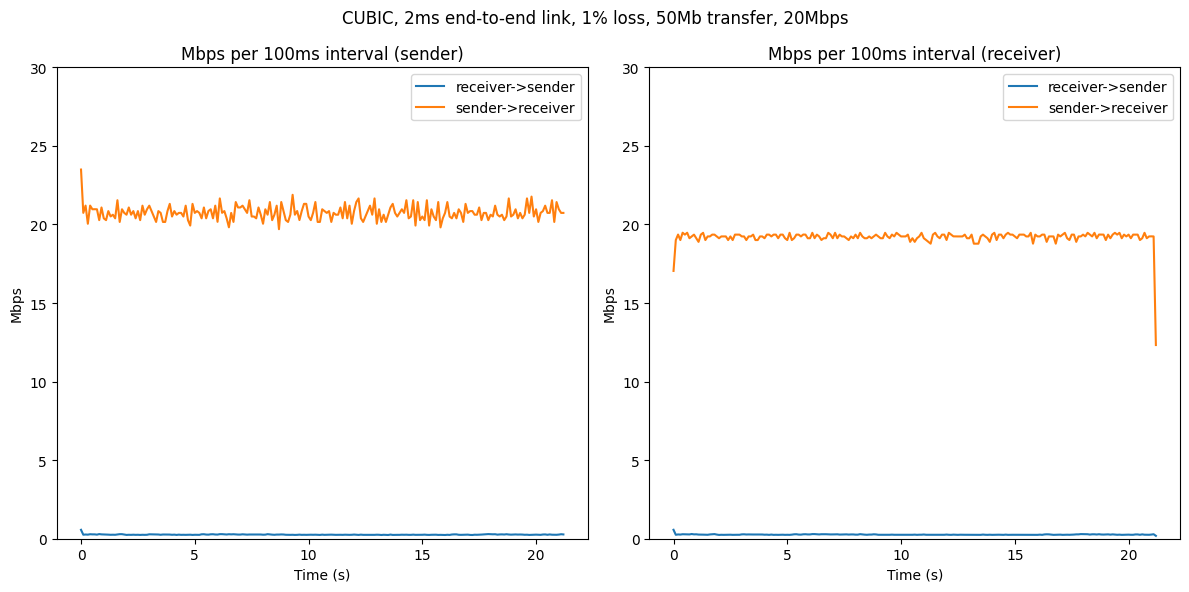

In [134]:
# 2ms delay - CUBIC
bw = 20
delay = 2
loss = 1
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 {delay} --delay2 0  "
          f"--loss1 {loss} -t 1 "
          f"picoquic "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)

plot_all(f"CUBIC, {delay}ms end-to-end link, {loss}% loss, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --loss1 2 -t 1 picoquic -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 cubic &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp cubic /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-12-01 12:56:30", "proxy_type": "none", "data_size": 50000000, "cca": "cubic"}, "outputs": [{"success": true, "timeout": false, "time_s": 21.532592, "throughput_mbps": 18.576490930585596, "additional_data": {"num_spurious_receiver": 0, "num_spurious_sender": 0}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --loss1 2 -t 1 picoquic -n 50000000', returncode=0)


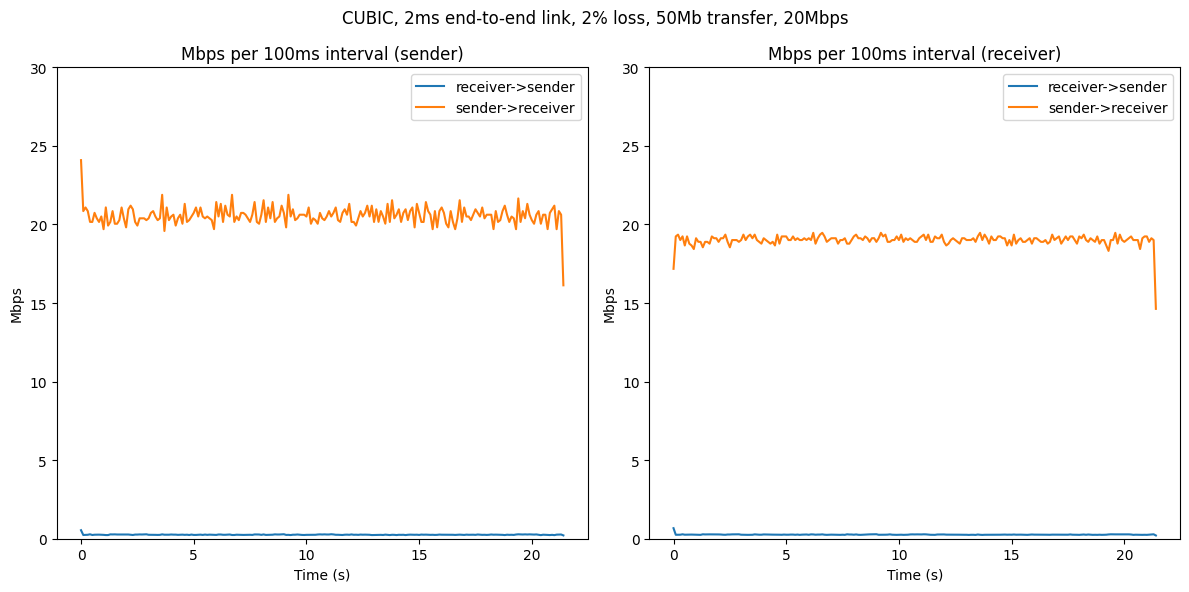

In [138]:
# 2ms delay - CUBIC
bw = 20
delay = 2
loss = 2
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 {delay} --delay2 0  "
          f"--loss1 {loss} -t 1 "
          f"picoquic "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)

plot_all(f"CUBIC, {delay}ms end-to-end link, {loss}% loss, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --loss1 8 -t 1 picoquic -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 cubic &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp cubic /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-12-01 12:54:09", "proxy_type": "none", "data_size": 50000000, "cca": "cubic"}, "outputs": [{"success": true, "timeout": false, "time_s": 23.571947, "throughput_mbps": 16.969323747418912, "additional_data": {"num_spurious_receiver": 2, "num_spurious_sender": 2}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --loss1 8 -t 1 picoquic -n 50000000', returncode=0)


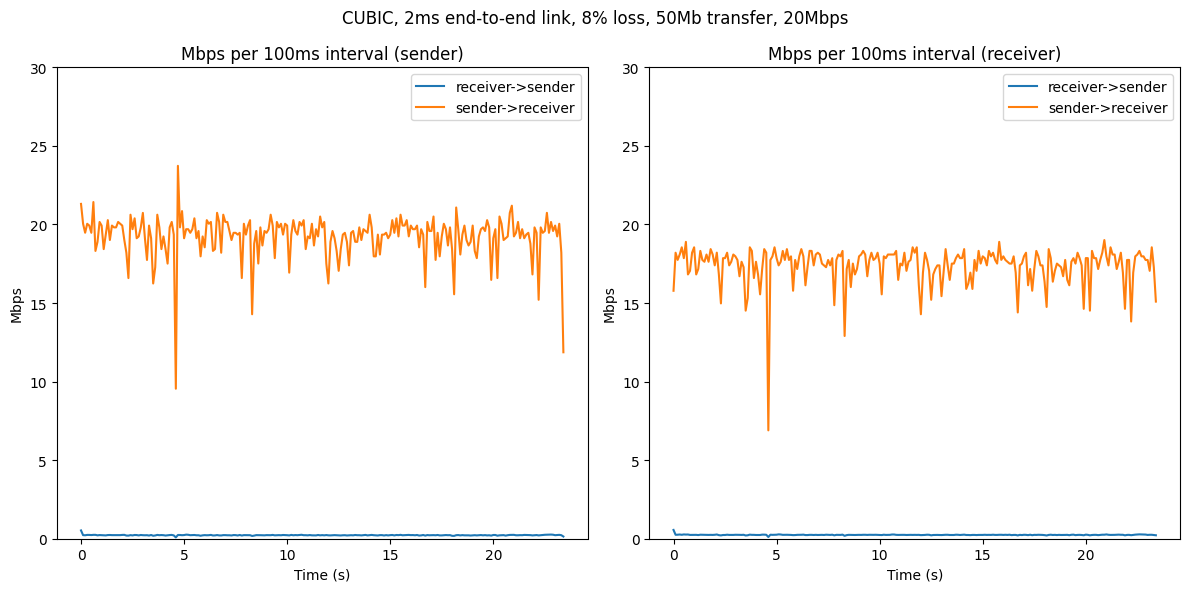

In [137]:
# 2ms delay - CUBIC
bw = 20
delay = 2
loss = 8
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 {delay} --delay2 0  "
          f"--loss1 {loss} -t 1 "
          f"picoquic "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)

plot_all(f"CUBIC, {delay}ms end-to-end link, {loss}% loss, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --ge 0.2,40,80,2 -t 1 picoquic --congestion-control bbr -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 bbr &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp bbr /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-12-01 13:03:47", "proxy_type": "none", "data_size": 50000000, "cca": "bbr"}, "outputs": [{"success": true, "timeout": false, "time_s": 45.192849, "throughput_mbps": 8.850957814144445, "additional_data": {"num_spurious_receiver": 13, "num_spurious_sender": 0}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 2 --delay2 0  --ge 0.2,40,80,2 -t 1 picoquic --congestion-control bbr -n 50000000', returncode=0)


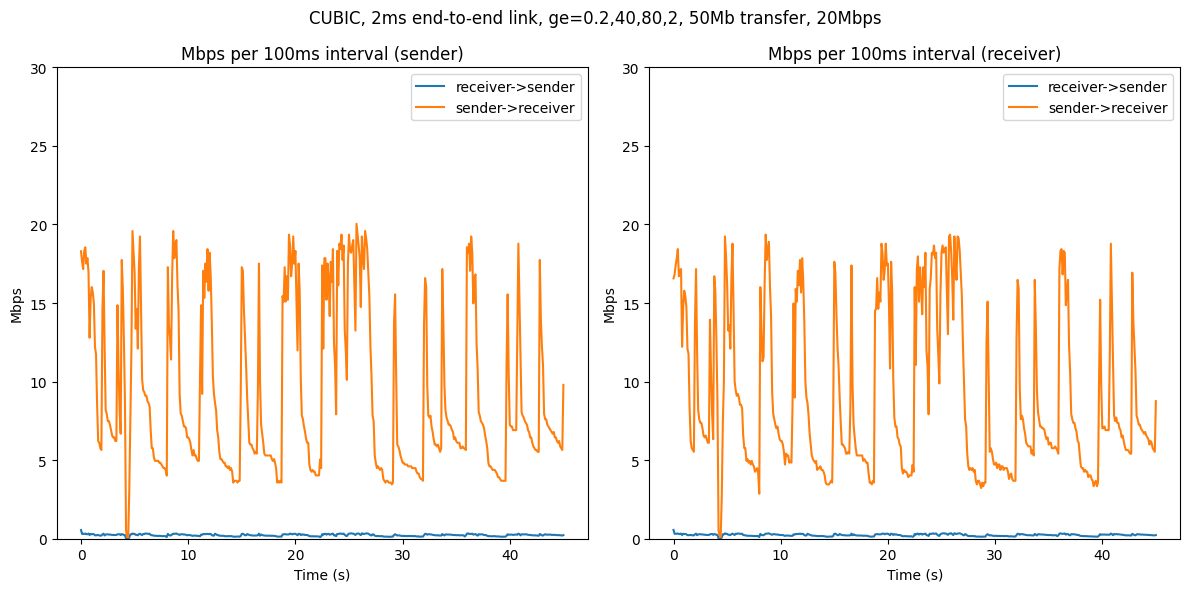

In [140]:
# 2ms delay - CUBIC; shorter loss bursts
bw = 20
delay = 2
ge = "0.2,40,80,2"
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 {delay} --delay2 0  "
          f"--ge {ge} -t 1 "
          f"picoquic "
          f"--congestion-control bbr "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)

plot_all(f"CUBIC, {delay}ms end-to-end link, ge={ge}, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 50 --delay2 0  --ge 0.2,40,80,2 -t 1 picoquic --congestion-control bbr -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 bbr &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp bbr /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-12-01 15:37:32", "proxy_type": "none", "data_size": 50000000, "cca": "bbr"}, "outputs": [{"success": true, "timeout": false, "time_s": 26.718414, "throughput_mbps": 14.970948500161724, "additional_data": {"num_spurious_receiver": 0, "num_spurious_sender": 0}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 50 --delay2 0  --ge 0.2,40,80,2 -t 1 picoquic --congestion-control bbr -n 50000000', returncode=0)


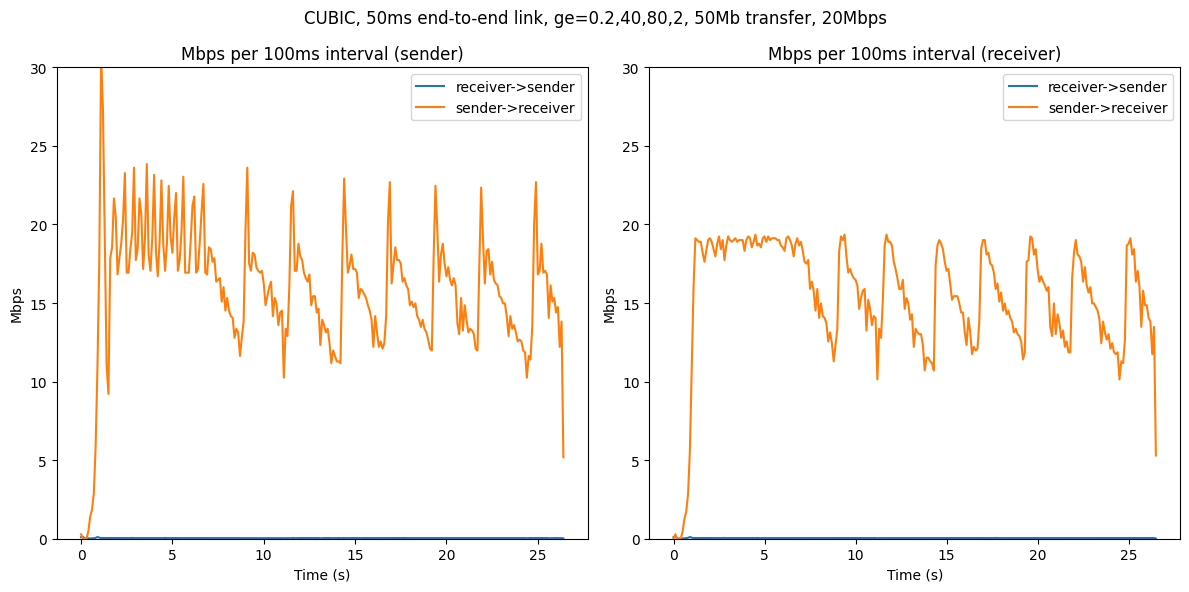

In [149]:
bw = 20
delay = 50
ge = "0.2,40,80,2"
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 {delay} --delay2 0  "
          f"--ge {ge} -t 1 "
          f"picoquic "
          f"--congestion-control bbr "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)

plot_all(f"CUBIC, {delay}ms end-to-end link, ge={ge}, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 50 --delay2 0  --ge 0.2,0.3,80,2 -t 1 picoquic --congestion-control bbr -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 bbr &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp bbr /tmp/sidekick-logs/client.log 0 50000000.html 
[SIDEKICK:WARN] PicoQUIC client failed to return result
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 50 --delay2 0  --ge 0.2,0.3,80,2 -t 1 picoquic --congestion-control bbr -n 50000000', returncode=1)


Traceback (most recent call last):
  File "/users/theaross/sidekick-downloads/emulation/main.py", line 529, in <module>
    main(args)
  File "/users/theaross/sidekick-downloads/emulation/main.py", line 521, in main
    args.benchmark(net, args)
  File "/users/theaross/sidekick-downloads/emulation/main.py", line 93, in benchmark_picoquic
    result = bm.run_benchmark(
             ^^^^^^^^^^^^^^^^^
  File "/users/theaross/sidekick-downloads/emulation/benchmark/http_benchmark.py", line 240, in run_benchmark
    output = self.run_client(timeout=timeout)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/users/theaross/sidekick-downloads/emulation/benchmark/http_benchmark.py", line 408, in run_client
    raise TimeoutError(f'timeout waiting for server stats')
TimeoutError: timeout waiting for server stats


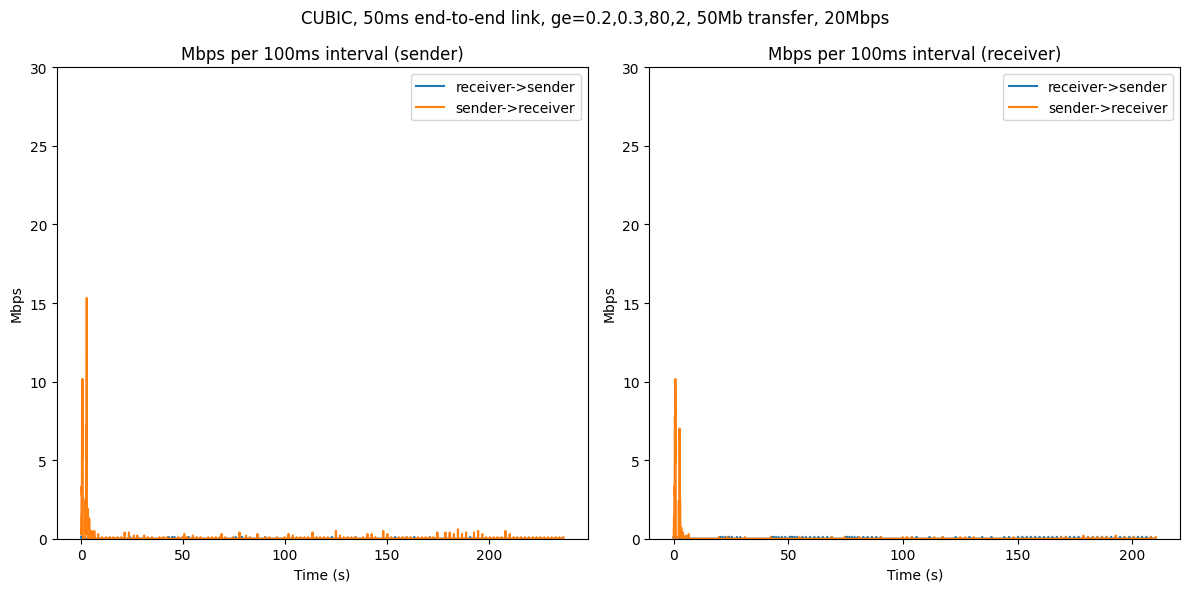

In [150]:
bw = 20
delay = 50
ge = "0.2,0.3,80,2"
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 {delay} --delay2 0  "
          f"--ge {ge} -t 1 "
          f"picoquic "
          f"--congestion-control bbr "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)

plot_all(f"CUBIC, {delay}ms end-to-end link, ge={ge}, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 30 --delay2 0  --loss1 0 -t 1 picoquic -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 cubic &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp cubic /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-12-01 15:26:23", "proxy_type": "none", "data_size": 50000000, "cca": "cubic"}, "outputs": [{"success": true, "timeout": false, "time_s": 21.315127, "throughput_mbps": 18.76601532798749, "additional_data": {"num_spurious_receiver": 0, "num_spurious_sender": 0}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 30 --delay2 0  --loss1 0 -t 1 picoquic -n 50000000', returncode=0)


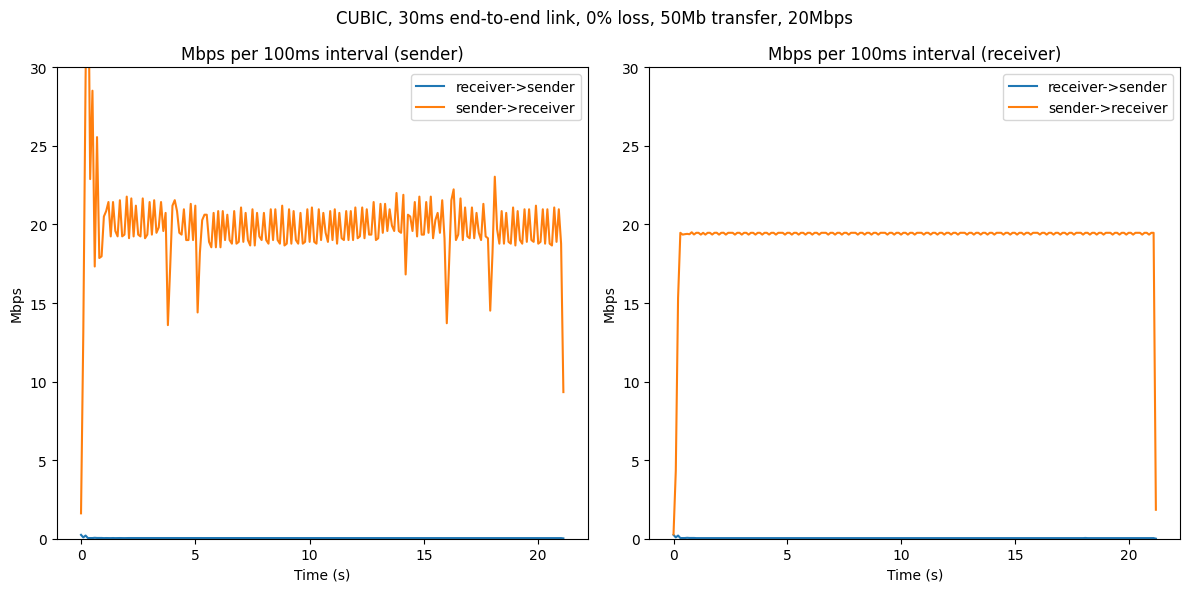

In [142]:
# 2ms delay - CUBIC
bw = 20
delay = 30
loss = 0
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 {delay} --delay2 0  "
          f"--loss1 {loss} -t 1 "
          f"picoquic "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)

plot_all(f"CUBIC, {delay}ms end-to-end link, {loss}% loss, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)

sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 30 --delay2 0  --loss1 0 -t 1 picoquic -n 50000000


*** Configuring hosts
h1 h2 e1 e2 p1 
[SIDEKICK:DEBUG] h1 tcpdump -i h1-eth0 -w /tmp/sidekick-logs/h1-eth0.pcap &
[SIDEKICK:DEBUG] h2 tcpdump -i h2-eth0 -w /tmp/sidekick-logs/h2-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth0 -w /tmp/sidekick-logs/p1-eth0.pcap &
[SIDEKICK:DEBUG] p1 tcpdump -i p1-eth1 -w /tmp/sidekick-logs/p1-eth1.pcap &
[SIDEKICK:DEBUG] h2 ./deps/picoquic/picoquic_sample server 4433 deps/certs/out/leaf_cert.pem deps/certs/out/leaf_cert.key . 50000000 cubic &
[SIDEKICK:DEBUG] h1 ./deps/picoquic/picoquic_sample client 172.16.2.10 4433 /tmp cubic /tmp/sidekick-logs/client.log 0 50000000.html 
*** Stopping 0 controllers

*** Stopping 4 links
....
*** Stopping 0 switches

*** Stopping 5 hosts
h1 h2 e1 e2 p1 
*** Done


Start benchmark: server 172.16.2.10:4433, client 172.16.1.10, proxy 172.16.1.11
{"inputs": {"label": "NO_LABEL", "protocol": "PICOQUIC", "num_trials": 1, "start_time": "2025-12-01 15:33:48", "proxy_type": "none", "data_size": 50000000, "cca": "cubic"}, "outputs": [{"success": true, "timeout": false, "time_s": 21.33574, "throughput_mbps": 18.74788500422296, "additional_data": {"num_spurious_receiver": 0, "num_spurious_sender": 0}}]}
CompletedProcess(args='sudo -E python3 emulation/main.py --tcpdump --bw1 20 --bw2 20 --delay1 30 --delay2 0  --loss1 0 -t 1 picoquic -n 50000000', returncode=0)


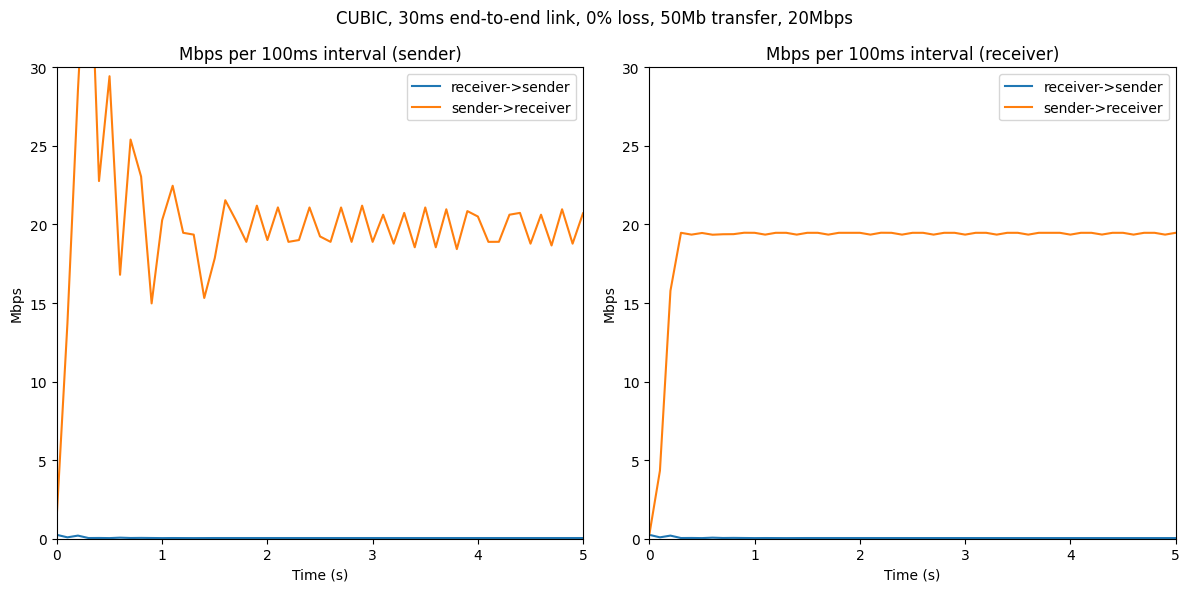

In [146]:
bw = 20
delay = 30
loss = 0
mbyte = 50
bytes_ = int(mbyte * 1_000_000)

cmd = (f"sudo -E python3 emulation/main.py --tcpdump "
          f"--bw1 {bw} --bw2 {bw} --delay1 {delay} --delay2 0  "
          f"--loss1 {loss} -t 1 "
          f"picoquic "
          f"-n {bytes_}")

print(cmd)
res = subprocess.run(cmd, capture_output=False, text=True, shell=True)
print(res)

plot_all(f"CUBIC, {delay}ms end-to-end link, {loss}% loss, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)

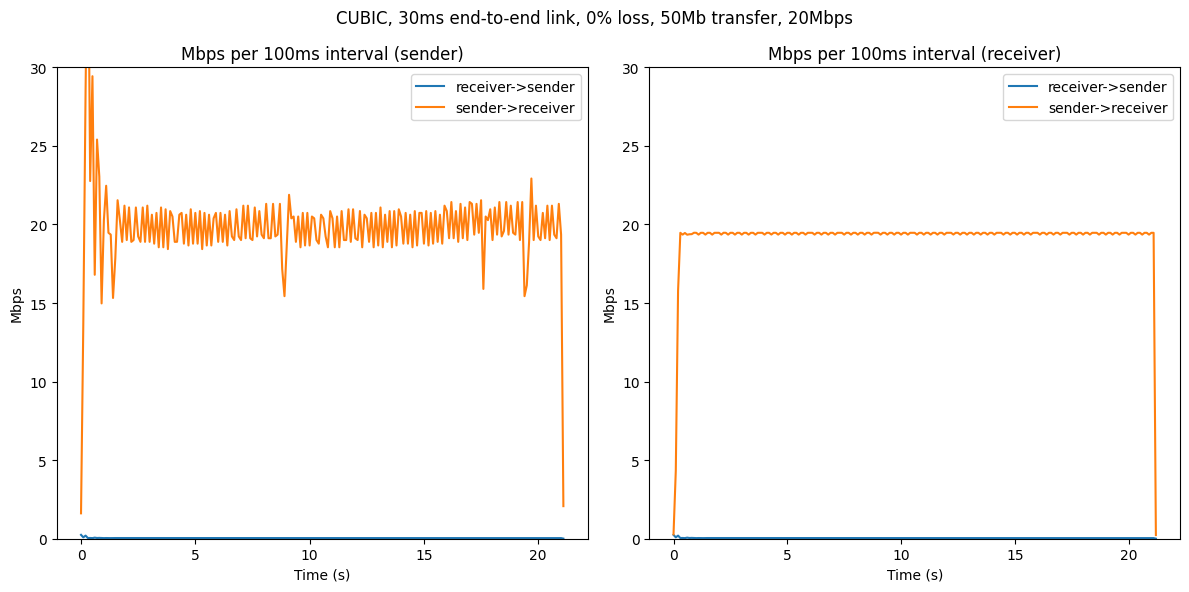

In [148]:
plot_all(f"CUBIC, {delay}ms end-to-end link, {loss}% loss, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)

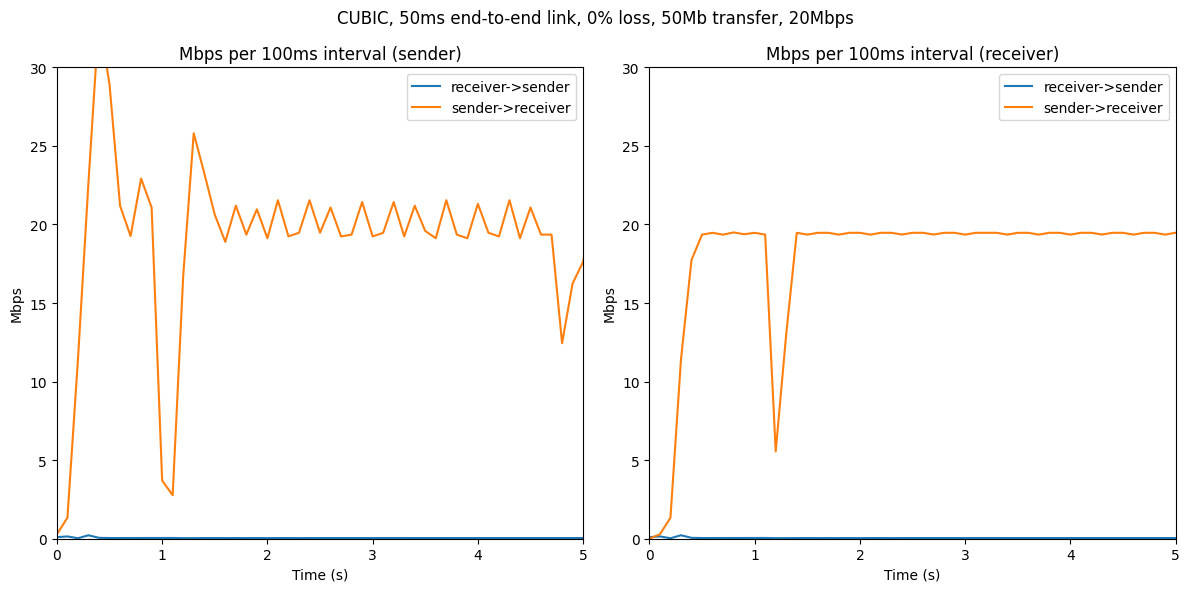

In [145]:
plot_all(f"CUBIC, {delay}ms end-to-end link, {loss}% loss, {mbyte}Mb transfer, {bw}Mbps", with_proxy=False)